In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
df = yf.Ticker("SMT.L").history(period="max")

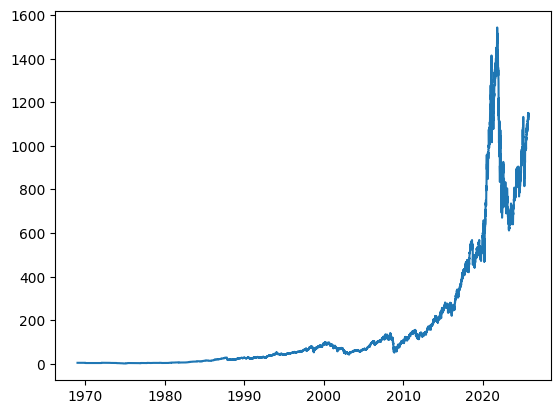

In [3]:
plt.plot(df['Close'])

In [4]:
df['MA'] = df['Close'].rolling(50).mean()
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,MA
Date,,,,,,,,,
1968-12-31 00:00:00+01:00,4.802321,4.802321,4.802321,4.802321,0,0.0,0.0,0.0,NaN
1969-01-01 00:00:00+01:00,4.802321,4.802321,4.802321,4.802321,0,0.0,0.0,0.0,NaN
1969-01-02 00:00:00+01:00,4.802321,4.802321,4.802321,4.802321,0,0.0,0.0,0.0,NaN
1969-01-03 00:00:00+01:00,4.802321,4.802321,4.802321,4.802321,0,0.0,0.0,0.0,NaN
1969-01-06 00:00:00+01:00,4.802321,4.802321,4.802321,4.802321,0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
2025-10-06 00:00:00+01:00,1147.000000,1150.000000,1135.000000,1135.000000,2344149,0.0,0.0,0.0,1101.75
2025-10-07 00:00:00+01:00,1138.000000,1147.000000,1133.500000,1133.500000,2083637,0.0,0.0,0.0,1102.76
2025-10-08 00:00:00+01:00,1138.500000,1151.000000,1135.000000,1151.000000,1942256,0.0,0.0,0.0,1104.24


Text(0.5, 1.0, 'SMT.L Close vs. Moving Average')

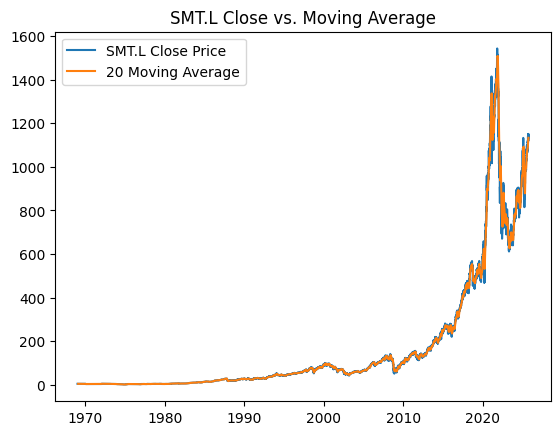

In [5]:
TICKER = 'SMT.L'

WINDOW = (20)

df = yf.Ticker(TICKER).history(period="max")
df['MA'] = df['Close'].rolling(WINDOW).mean()

plt.plot(df['Close']) 
plt.plot(df['MA'])
plt.legend([f'{TICKER} Close Price', f'{WINDOW} Moving Average'])
plt.title(f'{TICKER} Close vs. Moving Average')

In [6]:
df.columns = df.columns.get_level_values(0)

def add_ma_strategy(df):

    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)

    return df

df = add_ma_strategy(df)
df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1  # This shows what the multiplier would have been if you bought and held for 50 years.
df['strategy_cumulative'] =  np.cumprod(1 + df['Close'].pct_change() * df['Strategy'].shift()) - 1 

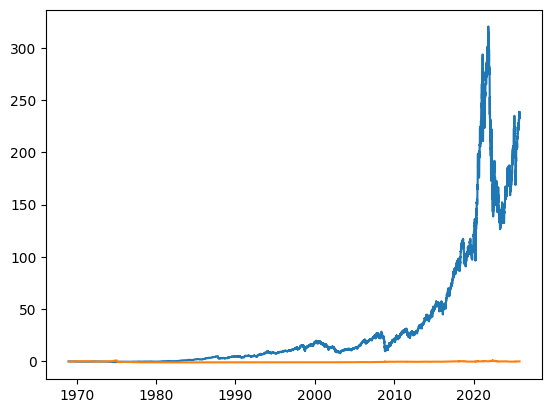

In [7]:
plt.plot(df['asset_cumulative'])
plt.plot(df['strategy_cumulative'])

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,MA,Strategy,asset_cumulative,strategy_cumulative
Date,,,,,,,,,,,,
2024-11-08 00:00:00+00:00,915.358627,916.158578,898.630379,905.559021,1736419,0.0,0.0,0.0,868.950677,NaN,NaN,NaN
2024-11-11 00:00:00+00:00,914.958621,928.557981,912.981720,927.158081,1990074,0.0,0.0,0.0,872.210532,1.0,0.023852,0.023852
2024-11-12 00:00:00+00:00,923.358220,932.157809,913.493615,926.158081,2062445,0.0,0.0,0.0,876.310345,1.0,0.022747,0.022747
2024-11-13 00:00:00+00:00,922.358324,941.357465,921.402312,940.957458,1898742,0.0,0.0,0.0,881.010135,1.0,0.039090,0.039090
2024-11-14 00:00:00+00:00,942.957352,945.157265,933.957759,941.957397,1459284,0.0,0.0,0.0,884.999954,1.0,0.040194,0.040194
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-06 00:00:00+01:00,1147.000000,1150.000000,1135.000000,1135.000000,2344149,0.0,0.0,0.0,1128.625000,1.0,0.253369,0.334332
2025-10-07 00:00:00+01:00,1138.000000,1147.000000,1133.500000,1133.500000,2083637,0.0,0.0,0.0,1129.800000,1.0,0.251713,0.332569
2025-10-08 00:00:00+01:00,1138.500000,1151.000000,1135.000000,1151.000000,1942256,0.0,0.0,0.0,1131.350000,1.0,0.271038,0.353142


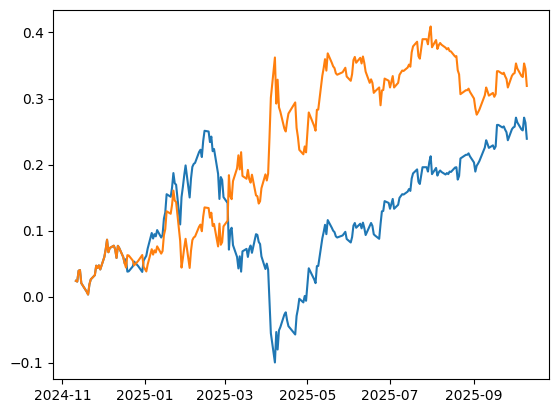

In [17]:
def get_data():
    df = yf.Ticker(TICKER).history(period="1y")
    df.columns = df.columns.get_level_values(0)
    df['MA'] = df['Close'].rolling(WINDOW).mean()

    return df.dropna()

def add_strategy(df):
    df.columns = df.columns.get_level_values(0)
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df

def test_strategy(df):
    df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1
    df['strategy_cumulative'] = np.cumprod(1 + df['Close'].pct_change() * df['Strategy']) - 1
    plt.plot(df['asset_cumulative'])
    plt.plot(df['strategy_cumulative'])
    return df

def main():
    df = get_data()
    df = add_strategy(df)
    df = test_strategy(df)
    return df

main()